GPU detected: /physical_device:GPU:0
Dataset extracted successfully
BASE_PATH adjusted to: /content/final_dataset/final_dataset

--- Loading class: hungry ---
  Loaded: 200 / 200 files

--- Loading class: burping ---
  Loaded: 40 / 40 files

--- Loading class: belly_pain ---
  Loaded: 40 / 40 files

--- Loading class: discomfort ---
  Loaded: 40 / 40 files

--- Loading class: tired ---
  Loaded: 40 / 40 files

Total samples : 360
Feature shape : (360, 100, 120)

Samples per class:
  hungry           200  [OK]
  burping           40  [LOW — consider more augmentation]
  belly_pain        40  [LOW — consider more augmentation]
  discomfort        40  [LOW — consider more augmentation]
  tired             40  [LOW — consider more augmentation]

Class mapping:
  0 → belly_pain
  1 → burping
  2 → discomfort
  3 → hungry
  4 → tired

X_train : (288, 100, 120)
X_test  : (72, 100, 120)

Mean shape : (120,)  (should be (120,))
Std shape  : (120,)   (should be (120,))
Normalization saved

Class

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_5 (Conv1D)               │ (None, 100, 32)        │        11,552 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 100, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_5 (MaxPooling1D)  │ (None, 50, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 50, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_5 (Bidirectional) │ (None, 64)             │        16,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,565 (119.39 KB)

 Trainable params: 30,501 (119.14 KB)

 Non-trainable params: 64 (256.00 B)

Epoch 1/100
16/18 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.1575 - loss: 1.6512
Epoch 1: val_accuracy improved from None to 0.25000, saving model to /content/drive/MyDrive/Audio_Model/multiclass_cry_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Audio_Model/multiclass_cry_model.keras
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - accuracy: 0.1667 - loss: 1.6451 - val_accuracy: 0.2500 - val_loss: 1.5946 - learning_rate: 0.0010
Epoch 2/100
15/18 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.3191 - loss: 1.4275
Epoch 2: val_accuracy improved from 0.25000 to 0.26389, saving model to /content/drive/MyDrive/Audio_Model/multiclass_cry_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/Audio_Model/multiclass_cry_model.keras
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.3194 - loss: 1.5135 - val_accuracy: 0.2639 - val_loss: 1.5498 - learning_rate: 0.0010
Epoch 3/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.3393 - loss: 1.4716
Epo

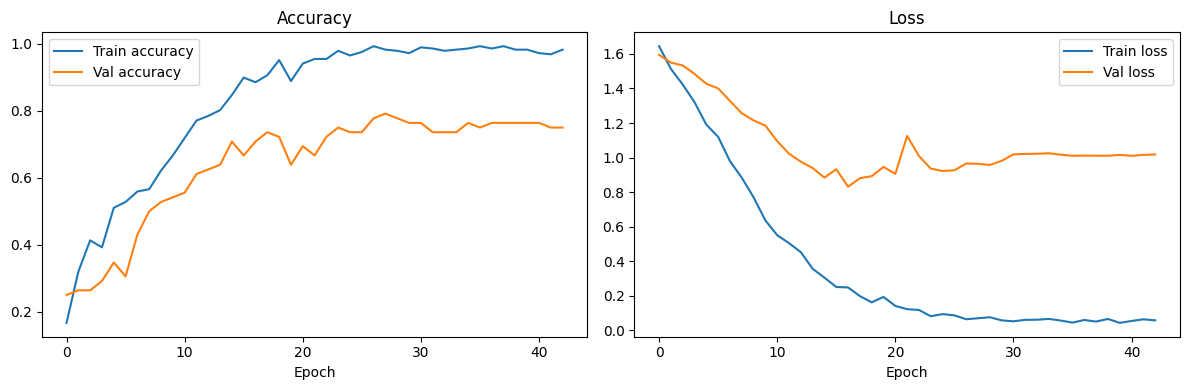

Training curve saved

TRAINING COMPLETED — FILES SAVED
1. multiclass_cry_model.keras
2. audio_mean.npy        (shape: (120,))
3. audio_std.npy         (shape: (120,))
4. audio_class_names.npy
5. training_curve.png


In [14]:
import os
import zipfile
import numpy as np
import librosa
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv1D,
    MaxPooling1D,
    BatchNormalization,
    Dropout,
    Bidirectional,
    LSTM,
    Dense,
    GlobalAveragePooling1D
)
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

# =========================================================
# STEP 4 — GPU CHECK
# =========================================================

gpus = tf.config.list_physical_devices('GPU')

if gpus:
    print(f"GPU detected: {gpus[0].name}")
else:
    print("WARNING: No GPU — go to Runtime > Change runtime type > T4 GPU")

# =========================================================
# STEP 5 — PATHS
# =========================================================

ZIP_PATH = (
    "/content/drive/MyDrive/"
    "Audio_Model/"
    "final_dataset.zip"
)

EXTRACT_PATH   = "/content/final_dataset"

MODEL_SAVE_PATH = (
    "/content/drive/MyDrive/"
    "Audio_Model/"
    "multiclass_cry_model.keras"
)

MEAN_SAVE_PATH = (
    "/content/drive/MyDrive/"
    "Audio_Model/"
    "audio_mean.npy"
)

STD_SAVE_PATH = (
    "/content/drive/MyDrive/"
    "Audio_Model/"
    "audio_std.npy"
)

CLASSES_SAVE_PATH = (
    "/content/drive/MyDrive/"
    "Audio_Model/"
    "audio_class_names.npy"
)

# =========================================================
# STEP 6 — EXTRACT DATASET
# =========================================================

with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
    zip_ref.extractall(EXTRACT_PATH)

print("Dataset extracted successfully")

# =========================================================
# STEP 7 — CONFIGURATION
# =========================================================

CLASSES = [
    "hungry",
    "burping",
    "belly_pain",
    "discomfort",
    "tired"
]

SAMPLE_RATE = 16000
N_MFCC      = 40
MAX_LEN     = 100

# Each feature vector is (MAX_LEN, N_MFCC*3) = (100, 120)
FEATURE_DIM = N_MFCC * 3   # 120

SUPPORTED_EXTENSIONS = (".wav", ".mp3", ".flac", ".ogg")

# =========================================================
# STEP 8 — RESOLVE BASE PATH
# =========================================================

BASE_PATH = EXTRACT_PATH

extracted_folder_name = os.path.basename(EXTRACT_PATH)
potential_base_path   = os.path.join(EXTRACT_PATH, extracted_folder_name)

if os.path.exists(potential_base_path):
    found = sum(
        1 for cls in CLASSES
        if os.path.exists(os.path.join(potential_base_path, cls))
    )
    if found > 0:
        BASE_PATH = potential_base_path
        print(f"BASE_PATH adjusted to: {BASE_PATH}")

# =========================================================
# STEP 9 — FEATURE EXTRACTION
# =========================================================

def extract_features(file_path):
    """
    Extracts MFCC + delta + delta2.
    Returns shape (MAX_LEN, FEATURE_DIM) = (100, 120)
    Returns None on failure.
    """
    try:
        audio, sr = librosa.load(file_path, sr=SAMPLE_RATE)

        if audio is None or len(audio) == 0:
            raise ValueError("Empty audio")

        if len(audio) < sr * 0.5:
            raise ValueError("Audio too short (< 0.5 sec)")

        # Amplitude normalization
        audio = librosa.util.normalize(audio)
        # Add pre-emphasis filter
        audio = librosa.effects.preemphasis(audio)

        mfcc    = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=N_MFCC)
        delta   = librosa.feature.delta(mfcc)
        delta2  = librosa.feature.delta(mfcc, order=2)

        features = np.concatenate([mfcc, delta, delta2], axis=0)

        # Pad or truncate to MAX_LEN frames
        if features.shape[1] < MAX_LEN:
            pad_width = MAX_LEN - features.shape[1]
            features = np.pad(
                features,
                pad_width=((0, 0), (0, pad_width)),
                mode='constant'
            )
        else:
            features = features[:, :MAX_LEN]

        # Transpose → (MAX_LEN, FEATURE_DIM) = (100, 120)
        return features.T

    except Exception as e:
        print(f"  Skipped {os.path.basename(file_path)}: {e}")
        return None

# =========================================================
# STEP 10 — LOAD DATASET
# =========================================================

X = []
y = []

for cls in CLASSES:

    class_folder = os.path.join(BASE_PATH, cls)

    print(f"\n--- Loading class: {cls} ---")

    if not os.path.exists(class_folder):
        print(f"  WARNING: folder missing: {class_folder}")
        continue

    files = [
        f for f in os.listdir(class_folder)
        if f.lower().endswith(SUPPORTED_EXTENSIONS)
    ]

    valid = 0

    for file_name in files:
        file_path = os.path.join(class_folder, file_name)
        features  = extract_features(file_path)

        if features is not None:
            X.append(features)
            y.append(cls)
            valid += 1

    print(f"  Loaded: {valid} / {len(files)} files")

X = np.array(X)   # shape: (N, 100, 120)
y = np.array(y)

print(f"\nTotal samples : {len(X)}")
print(f"Feature shape : {X.shape}")

# Warn if any class has too few samples
print("\nSamples per class:")
for cls in CLASSES:
    count = np.sum(y == cls)
    status = "OK" if count >= 100 else "LOW — consider more augmentation"
    print(f"  {cls:<15} {count:>4}  [{status}]")

# =========================================================
# STEP 11 — LABEL ENCODING
# =========================================================

label_encoder = LabelEncoder()
y_encoded     = label_encoder.fit_transform(y)
class_names   = label_encoder.classes_

print("\nClass mapping:")
for idx, label in enumerate(class_names):
    print(f"  {idx} → {label}")

# =========================================================
# STEP 12 — TRAIN / TEST SPLIT
# =========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print(f"\nX_train : {X_train.shape}")
print(f"X_test  : {X_test.shape}")

# =========================================================
# STEP 13 — NORMALIZATION (FIX 1)
# =========================================================
#
# WRONG (your original code):
#   mean = np.mean(X_train)        → scalar (1 number)
#   std   = np.std(X_train)         → scalar (1 number)
#   This collapses all 120 feature dims into one value.
#   The model cannot distinguish MFCC from delta coeffs.
#
# CORRECT:
#   mean = np.mean(X_train, axis=(0,1))  → shape (120,)
#   std  = np.std(X_train, axis=(0,1))   → shape (120,)
#   Each of the 120 feature dimensions is normalized
#   independently, preserving the inter-feature structure.
#
# =========================================================

mean = np.mean(X_train, axis=(0, 1))   # shape: (120,)
std  = np.std(X_train,  axis=(0, 1))   # shape: (120,)

print(f"\nMean shape : {mean.shape}  (should be (120,))")
print(f"Std shape  : {std.shape}   (should be (120,))")

# Guard: replace any zero-variance dimension with 1
safe_std = np.where(std == 0, 1.0, std)

X_train = (X_train - mean) / safe_std
X_test  = (X_test  - mean) / safe_std

# Save normalization — these shapes MUST be used in inference too
np.save(MEAN_SAVE_PATH, mean)
np.save(STD_SAVE_PATH,  safe_std)

print("Normalization saved")

# =========================================================
# STEP 14 — CLASS WEIGHTS
# =========================================================

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights = dict(enumerate(class_weights))

print("\nClass weights:")
for k, v in class_weights.items():
    print(f"  {class_names[k]:<15} {v:.3f}")

# =========================================================
# STEP 15 — BUILD MODEL (FIX 2)
# =========================================================
#
# ORIGINAL MODEL PROBLEMS:
#   - 2 CNN blocks + large BiLSTM = ~500k parameters
#   - Way too many parameters for ~200 training samples
#   - Model memorizes noise, cannot generalize
#
# FIXED MODEL:
#   - 1 CNN block (32 filters) — extracts local patterns
#   - 1 BiLSTM (32 units) — captures temporal structure
#   - Much lower dropout (0.2) — less aggressive regularization
#   - Total params ~50k — appropriate for this data size
#
# =========================================================

model = Sequential([

    # ---------------------------------
    # CNN BLOCK — local pattern extractor
    # Reduced from 64 filters to 32
    # ---------------------------------
    Conv1D(
        32,
        kernel_size=3,
        activation='relu',
        padding='same',
        input_shape=(MAX_LEN, FEATURE_DIM)
    ),
    BatchNormalization(),
    MaxPooling1D(2),
    Dropout(0.2),

    # ---------------------------------
    # BiLSTM — temporal sequence learner
    # Reduced from 64 to 32 units
    # ---------------------------------
    Bidirectional(
        LSTM(32, return_sequences=False)
    ),
    Dropout(0.3),

    # ---------------------------------
    # Dense classification head
    # Reduced from 64 to 32 units
    # ---------------------------------
    Dense(32, activation='relu'),
    Dropout(0.2),

    # ---------------------------------
    # Output — 5 classes
    # ---------------------------------
    Dense(len(CLASSES), activation='softmax')
])

# =========================================================
# STEP 16 — COMPILE
# =========================================================

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("\n--- Model Summary ---")
model.summary()

# =========================================================
# STEP 17 — CALLBACKS (FIX 3)
# =========================================================
#
# ORIGINAL: patience=5 on EarlyStopping
# With a small noisy dataset, val_loss fluctuates a lot.
# patience=5 stops training around epoch 8–12 — far too early.
#
# FIXED: patience=15, epochs=100
# Gives the model enough time to find a stable minimum.
#
# =========================================================

early_stop = EarlyStopping(
    monitor='val_accuracy',        # monitor accuracy, not loss
    patience=15,                   # was 5 — now 15
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,                    # was 2 — now 5
    min_lr=1e-6,
    verbose=1
)

checkpoint = ModelCheckpoint(
    MODEL_SAVE_PATH,
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

# =========================================================
# STEP 18 — TRAIN
# =========================================================

history = model.fit(
    X_train, y_train,
    epochs=100,                    # was 30 — now 100
    batch_size=16,                 # was 8 — slightly larger
    validation_data=(X_test, y_test),
    class_weight=class_weights,
    callbacks=[early_stop, reduce_lr, checkpoint],
    verbose=1
)

# =========================================================
# STEP 19 — EVALUATE
# =========================================================

loss, accuracy = model.evaluate(X_test, y_test, verbose=0)

print("\n===================================")
print("FINAL TEST ACCURACY")
print("===================================")
print(f"Loss     : {loss:.4f}")
print(f"Accuracy : {accuracy:.4f}  ({accuracy*100:.1f}%)")

if accuracy < 0.60:
    print("\nWARNING: Accuracy still below 60%")
    print("Most likely cause: not enough training samples.")
    print("Go back to dataset pipeline and raise TARGET_MINIMUM to 150.")
elif accuracy < 0.75:
    print("\nAcceptable — consider adding more real audio samples.")
else:
    print("\nGood accuracy for this dataset size.")

# =========================================================
# STEP 20 — CLASSIFICATION REPORT
# =========================================================

predictions       = model.predict(X_test, verbose=0)
predicted_classes = np.argmax(predictions, axis=1)

print("\n===================================")
print("CLASSIFICATION REPORT")
print("===================================")
print(classification_report(
    y_test,
    predicted_classes,
    target_names=class_names
))

# =========================================================
# STEP 21 — CONFUSION MATRIX
# =========================================================

print("===================================")
print("CONFUSION MATRIX")
print("===================================")
cm = confusion_matrix(y_test, predicted_classes)
print(cm)

# =========================================================
# STEP 22 — TRAINING CURVE
# =========================================================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history.history['accuracy'],     label='Train accuracy')
ax1.plot(history.history['val_accuracy'], label='Val accuracy')
ax1.set_title('Accuracy')
ax1.set_xlabel('Epoch')
ax1.legend()

ax2.plot(history.history['loss'],     label='Train loss')
ax2.plot(history.history['val_loss'], label='Val loss')
ax2.set_title('Loss')
ax2.set_xlabel('Epoch')
ax2.legend()

plt.tight_layout()
plt.savefig(
    "/content/drive/MyDrive/Audio_Model/training_curve.png",
    dpi=150
)
plt.show()
print("Training curve saved")

# =========================================================
# STEP 23 — SAVE CLASS NAMES
# =========================================================

np.save(CLASSES_SAVE_PATH, class_names)

print("\n===================================")
print("TRAINING COMPLETED — FILES SAVED")
print("===================================")
print("1. multiclass_cry_model.keras")
print("2. audio_mean.npy        (shape: (120,))")
print("3. audio_std.npy         (shape: (120,))")
print("4. audio_class_names.npy")
print("5. training_curve.png")

In [8]:
# =========================================================
# MULTICLASS AUDIO MODEL TESTING
# FINAL VERSION
# =========================================================
#
# TEST AUDIO FILE:
# /content/test.wav
#
# CLASSES:
# hungry
# burping
# belly_pain
# discomfort
# tired
#
# =========================================================

# =========================================================
# STEP 1 — IMPORTS
# =========================================================

import os
import numpy as np
import librosa
import tensorflow as tf

# =========================================================
# STEP 2 — GPU CHECK
# =========================================================

gpus = tf.config.list_physical_devices("GPU")

if gpus:

    print(f"GPU detected: {gpus[0].name}")

else:

    print("WARNING: No GPU found")
    print("Runtime → Change runtime type → T4 GPU")

# =========================================================
# STEP 3 — CONFIGURATION
# =========================================================

SAMPLE_RATE = 16000

N_MFCC = 40

MAX_LEN = 100

CONFIDENCE_THRESHOLD = 0.65

# =========================================================
# STEP 4 — PATHS
# =========================================================

MODEL_PATH = (
    "/content/drive/MyDrive/"
    "Audio_Model/"
    "multiclass_cry_model.keras"
)

MEAN_PATH = (
    "/content/drive/MyDrive/"
    "Audio_Model/"
    "audio_mean.npy"
)

STD_PATH = (
    "/content/drive/MyDrive/"
    "Audio_Model/"
    "audio_std.npy"
)

CLASSES_PATH = (
    "/content/drive/MyDrive/"
    "Audio_Model/"
    "audio_class_names.npy"
)

# Upload test file as:
TEST_AUDIO = "/content/drive/MyDrive/Audio_Model/test_data/discomfort.wav"

# =========================================================
# STEP 5 — CHECK FILES EXIST
# =========================================================

required_files = {

    "Model": MODEL_PATH,

    "Mean": MEAN_PATH,

    "Std": STD_PATH,

    "Class Names": CLASSES_PATH,

    "Test Audio": TEST_AUDIO
}

missing = []

for label, path in required_files.items():

    if not os.path.exists(path):

        missing.append(f"{label}: {path}")

if len(missing) > 0:

    raise FileNotFoundError(

        "\nMissing files:\n" +
        "\n".join(missing)
    )

print("\nAll required files found")

# =========================================================
# STEP 6 — LOAD MODEL
# =========================================================

model = tf.keras.models.load_model(
    MODEL_PATH
)

print("\nModel loaded successfully")

print(f"Model Input Shape: {model.input_shape}")

# =========================================================
# STEP 7 — LOAD NORMALIZATION VALUES
# =========================================================

mean = np.load(MEAN_PATH)

std = np.load(STD_PATH)

# Prevent divide by zero
safe_std = np.where(std == 0, 1.0, std)

# =========================================================
# STEP 8 — LOAD CLASS NAMES
# =========================================================

class_names = np.load(
    CLASSES_PATH,
    allow_pickle=True
)

class_names = class_names.tolist()

print("\nClasses:")

print(class_names)

# =========================================================
# STEP 9 — FEATURE EXTRACTION
# =========================================================

def extract_features(file_path):

    audio, sr = librosa.load(
        file_path,
        sr=SAMPLE_RATE
    )

    # -----------------------------------------
    # CHECK EMPTY AUDIO
    # -----------------------------------------

    if audio is None or len(audio) == 0:

        raise ValueError(
            "Audio file is empty"
        )

    # -----------------------------------------
    # MINIMUM AUDIO LENGTH CHECK
    # -----------------------------------------

    if len(audio) < sr * 2:

        raise ValueError(
            "Audio too short (< 2 sec)"
        )

    # -----------------------------------------
    # NORMALIZE AUDIO
    # -----------------------------------------

    audio = librosa.util.normalize(audio)

    print(f"\nAudio Duration: {len(audio)/sr:.2f} sec")

    # -----------------------------------------
    # PRE-EMPHASIS FILTER (NEW)
    # -----------------------------------------
    audio = librosa.effects.preemphasis(audio)

    # -----------------------------------------
    # MFCC
    # -----------------------------------------

    mfcc = librosa.feature.mfcc(
        y=audio,
        sr=sr,
        n_mfcc=N_MFCC
    )

    # -----------------------------------------
    # DELTA
    # -----------------------------------------

    delta = librosa.feature.delta(
        mfcc
    )

    # -----------------------------------------
    # DELTA DELTA
    # -----------------------------------------

    delta2 = librosa.feature.delta(
        mfcc,
        order=2
    )

    # -----------------------------------------
    # COMBINE FEATURES
    # -----------------------------------------

    features = np.concatenate(
        [mfcc, delta, delta2],
        axis=0
    )

    # -----------------------------------------
    # PAD / TRUNCATE
    # -----------------------------------------

    if features.shape[1] < MAX_LEN:

        pad_width = (
            MAX_LEN - features.shape[1]
        )

        features = np.pad(
            features,
            pad_width=((0,0),(0,pad_width)),
            mode='constant'
        )

    else:

        features = features[:, :MAX_LEN]

    # Final Shape:
    # (100, 120)

    return features.T

# =========================================================
# STEP 10 — PROCESS TEST AUDIO
# =========================================================

features = extract_features(
    TEST_AUDIO
)

print(f"\nFeature Shape: {features.shape}")

# =========================================================
# STEP 11 — NORMALIZE FEATURES
# =========================================================

features = (
    features - mean
) / safe_std

# =========================================================
# STEP 12 — SHAPE VALIDATION
# =========================================================

expected_shape = model.input_shape[1:]

actual_shape = features.shape

if actual_shape != expected_shape:

    raise ValueError(

        f"\nShape mismatch!\n"
        f"Expected: {expected_shape}\n"
        f"Got: {actual_shape}"
    )

# =========================================================
# STEP 13 — ADD BATCH DIMENSION
# =========================================================

features = np.expand_dims(
    features,
    axis=0
)

print(f"Final Input Shape: {features.shape}")

# =========================================================
# STEP 14 — PREDICTION
# =========================================================

prediction = model.predict(
    features,
    verbose=0
)

predicted_index = np.argmax(
    prediction
)

predicted_class = class_names[
    predicted_index
]

confidence = float(
    prediction[0][predicted_index]
)

# =========================================================
# STEP 15 — FINAL RESULT
# =========================================================

print("\n===================================")
print("FINAL PREDICTION")
print("===================================")

print(f"\nPredicted Class: {predicted_class}")

print(
    f"Confidence Score: "
    f"{confidence:.4f}"
)

# =========================================================
# STEP 16 — LOW CONFIDENCE WARNING
# =========================================================

if confidence < CONFIDENCE_THRESHOLD:

    print("\nWARNING:")
    print("Low confidence prediction")

    print(
        "Possible reasons:"
    )

    print("- unclear cry")
    print("- noisy audio")
    print("- unseen pattern")
    print("- mixed cry types")

# =========================================================
# STEP 17 — ALL CLASS SCORES
# =========================================================

print("\n===================================")
print("ALL CLASS PROBABILITIES")
print("===================================")

sorted_indices = np.argsort(
    prediction[0]
)[::-1]

for i in sorted_indices:

    class_name = class_names[i]

    score = float(
        prediction[0][i]
    )

    bar = "#" * int(score * 30)

    marker = ""

    if i == predicted_index:

        marker = " <-- predicted"

    print(
        f"{class_name:<15} "
        f"{score:.4f} "
        f"{bar}"
        f"{marker}"
    )

GPU detected: /physical_device:GPU:0

All required files found

Model loaded successfully
Model Input Shape: (None, 100, 120)

Classes:
['belly_pain', 'burping', 'discomfort', 'hungry', 'tired']

Audio Duration: 7.00 sec

Feature Shape: (100, 120)
Final Input Shape: (1, 100, 120)

FINAL PREDICTION

Predicted Class: burping
Confidence Score: 0.4590

Low confidence prediction
Possible reasons:
- unclear cry
- noisy audio
- unseen pattern
- mixed cry types

ALL CLASS PROBABILITIES
burping         0.4590 ############# <-- predicted
hungry          0.2886 ########
tired           0.2292 ######
belly_pain      0.0169 
discomfort      0.0063 
